In [1]:
!pip install diffusers transformers accelerate safetensors torch torchvision pillow matplotlib -q

In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: False


In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id
)

pipe = pipe.to('cpu')

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
pipe.enable_attention_slicing()

In [14]:
prompt = """
minimalist AI startup logo,
modern vector logo,
clean typography,
blue and white color palette,
professional branding,
flat design,
high quality logo
"""

In [15]:
negative_prompt = """
blurry,
low quality,
distorted text,
extra shapes,
watermark,
complex background"""

In [16]:
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=7,
    height=384,
    width=384
).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

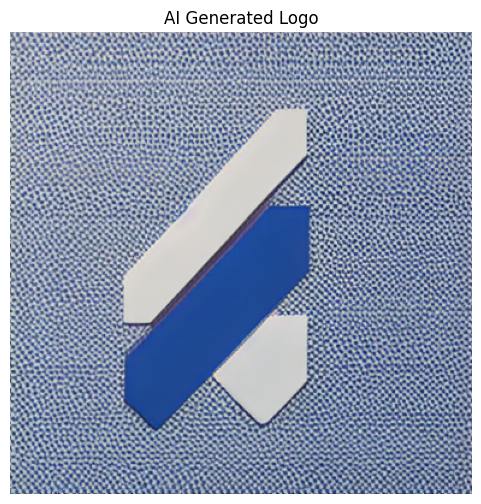

In [17]:
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("AI Generated Logo")
plt.show()

In [18]:
image.save("startup_logo.png")

print("Logo generated successfully!")

Logo generated successfully!
